<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Antibody Engineering

Comprehensive antibody engineering workflow using BioLM.ai models.

Antibodies are highly specific proteins with incredible binding prowess, important immune mediated interactions and high therapuetic potential. Benefiting from recent machine learning success in biology, and specifically protein design , computational antibody engineering has become extremely accesible. In the following guides, motivated by the binder design challenges proposed with the BenchBB dataset and the expediency of the BioLM SDK and API, several ML methods for antibody engineering are demonstrated.

---
## Previously

Using a structure and antigen conditioned candidate proposal method, 100 variants were generated for four of the proposed BenchBB targets ('IL7Ra', 'PDL-1', 'EGFR' and MBP) containing solved structures of antibodies in complex with the target deposited in the pdb. Then the varaints were scored using sequence based PLM's for a proxy on desiredd intrinsic poperties

---

One way to model binding is stucture prediction of variant and target compelex. From a predicted complex (assuming it is accurate) popular MD, energy based or rosetta caluculations can be used. Additionally many structure prediction methods offer confidence scores that can be used to rank the quality of poses and have even been demonstrated to correlate with binding success. Furthermore, large changes in rmsd and self consistency from a base structure in the case of varaint design (if the structure is available) can illuminate changes in epitope or neutrilization effects as well as being another way to rank variants.


## Import Required Libraries

In [1]:
from IPython.display import JSON
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import py3Dmol
from pathlib import Path
from sklearn.decomposition import PCA
from Bio import PDB
from Bio.PDB import *
import os
from biolmai import BioLM
from helpers.styling import apply_plot_styling
apply_plot_styling()

# Structure Based Scoring of Candidates

First generated variants are loaded along with the parent pdbs, then the structures of the variants with their specific target are co-folded with the results being compared against the solved structures.

In [38]:
samples_df = pd.read_csv("data/protein/benchbb_antibody_targets/variant_candidates.csv")
samples_df["Source"] = "Variant"
# Load PDBs from BenchBB dataset
target_pdbs = {}
pdb_dir = Path('data/protein/benchbb_antibody_targets')

for pdb_file in os.listdir(pdb_dir):
    if pdb_file.endswith('.pdb'):
        if '3c09' in pdb_file:
            target = 'EGFR'
        elif '5x8m' in pdb_file:
            target = 'PDL1'
        elif '5bjz' in pdb_file:
            target = 'MBP'
        elif '6p67' in pdb_file:
            target = 'IL-7RALPHA'
        else:
            continue
        
        # Store PDB string
        with open(pdb_dir / pdb_file, 'r') as f:
            target_pdbs[target] = f.read()

print(f"Loaded PDBs for targets: {list(target_pdbs.keys())}")

Loaded PDBs for targets: ['MBP', 'EGFR', 'PDL1', 'IL-7RALPHA']


In [6]:
from biotite.structure.io.pdb import PDBFile, get_structure
from biotite.structure.residues import get_residues
from biotite.structure.info import one_letter_code
from io import StringIO

# Explicit set of valid 3-letter residue names with defined 1-letter codes
VALID_RESIDUES = {
    "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY",
    "HIS", "ILE", "LEU", "LYS", "MET", "PHE", "PRO", "SER",
    "THR", "TRP", "TYR", "VAL"
}

def extract_sequences_from_pdb_str(pdb_str, chain_ids, verbose=False):
    """
    Extract ATOM-derived one-letter sequences from specified chains in a PDB string.
    
    Returns:
      dict: {chain_id: sequence_string}
    """
    pdbf = PDBFile.read(StringIO(pdb_str))
    structure = get_structure(pdbf, model=1)

    seqs = {}
    for chain in chain_ids:
        chain_array = structure[structure.chain_id == chain]
        if chain_array.array_length() == 0:
            print(f"⚠️ No atoms for chain '{chain}'")
            continue

        res_ids, res_names = get_residues(chain_array)
        if len(res_ids) == 0:
            print(f"⚠️ No residues found in chain '{chain}'")
            continue

        seq = ''
        for name in res_names:
            if name in VALID_RESIDUES:
                seq += one_letter_code(name)
            else:
                if verbose:
                    print(f"⚠️ Unknown residue '{name}' → skipping")
                # or optionally: seq += 'X'
        seqs[chain] = seq

    return seqs


In [7]:
# Extract sequences per target

target_chains = {
    "EGFR": ['H', 'L', 'D'],
    "PDL1": ['B', 'C', 'A'],
    "MBP": ['C', 'L', 'A'],
    "IL-7RALPHA": ['A', 'B', 'K'],
}



# Extract sequences
target_chain_seqs = {}
for target, pdb_str in target_pdbs.items():
    chains = target_chains[target]
    target_chain_seqs[target] = extract_sequences_from_pdb_str(pdb_str, chains)

# Example printout
for target, chain_dict in target_chain_seqs.items():
    print(f"\n{target}:")
    for chain_id, seq in chain_dict.items():
        print(f"  Chain {chain_id}: {seq[:30]}... (length {len(seq)})")


MBP:
  Chain C: EVQLVESGGGLVQPGGSLRLSCAASGFNLS... (length 228)
  Chain L: QMTQSPSSLSASVGDRVTITCRASQSVSSA... (length 213)
  Chain A: KIEEGKLVIWINGDKGYNGLAEVGKKFEKD... (length 367)

EGFR:
  Chain H: QVQLVQSGAEVKKPGASVKVSCKASGYTFT... (length 216)
  Chain L: DIQMTQSPSSLSASVGDRVTITCSASSSVT... (length 211)
  Chain D: KKVCNGIGIGEFKDSLSINATNIKHFKNCT... (length 191)

PDL1:
  Chain B: EVQLVESGGGLVQPGGSLRLSCAASGFTFS... (length 214)
  Chain C: IVLTQSPGTLSLSPGERATLSCRASQRVSS... (length 213)
  Chain A: AFTVTVPKDLYVVEYGSNMTIECKFPVEKE... (length 116)

IL-7RALPHA:
  Chain A: EVQLQQSGPELVKPGASVKMSCKASGYTFS... (length 223)
  Chain B: DIVMTQSHKFMSTLVGDRVSITCKASQDVS... (length 213)
  Chain K: DYSFSCYSQLEVNGSQHSLTCAFEDPDVNT... (length 188)


In [9]:

target_chain_seqs_standard = []
target_chain_mapping = target_chains = {
    "EGFR": {'H': 'heavy', 'L': 'light', 'D': 'target_seq'},
    "PDL1": {'B' : 'heavy', 'C': 'light', 'A': 'target_seq'},
    "MBP": {'C': 'heavy', 'L':'light', 'A': 'target_seq'},
    "IL-7RALPHA": {'A': 'heavy', 'B': 'light', 'K': 'target_seq'},
}

for target, chain_dict in target_chain_seqs.items():
    _parent_dict = {"target": target}
    for chain_id, seq in chain_dict.items():
        _parent_dict[target_chain_mapping[target][chain_id]] = seq
    target_chain_seqs_standard.append(_parent_dict)    

parent_df = pd.DataFrame(target_chain_seqs_standard)
parent_df["Source"] = "Parent"
parent_df

,target,heavy,light,target_seq,Source
0,MBP,EVQLVESGGGLVQPGGSLRLSCAASGFNLSSSSIHWVRQAPGKGLE...,QMTQSPSSLSASVGDRVTITCRASQSVSSAVAWYQQKPGKAPKLLI...,KIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKLEEK...,Parent
1,EGFR,QVQLVQSGAEVKKPGASVKVSCKASGYTFTSHWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCSASSSVTYMYWYQQKPGKAPKLL...,KKVCNGIGIGEFKDSLSINATNIKHFKNCTSISGDLHILPVAFRGD...,Parent
2,PDL1,EVQLVESGGGLVQPGGSLRLSCAASGFTFSRYWMSWVRQAPGKGLE...,IVLTQSPGTLSLSPGERATLSCRASQRVSSSYLAWYQQKPGQAPRL...,AFTVTVPKDLYVVEYGSNMTIECKFPVEKELDLAALIVYWEMEDKN...,Parent
3,IL-7RALPHA,EVQLQQSGPELVKPGASVKMSCKASGYTFSDYYMHWVKQSHGKSLE...,DIVMTQSHKFMSTLVGDRVSITCKASQDVSTTVAWYQQKPGQSPKL...,DYSFSCYSQLEVNGSQHSLTCAFEDPDVNTTFEICGALVEVKCLNF...,Parent


In [10]:
samples_df = pd.concat([parent_df, samples_df])

In [21]:
from biotite.structure.io.pdb import PDBFile, get_structure
from io import StringIO

def extract_target_chain_pdbs(target_pdbs: dict, target_chains: dict) -> dict:
    """
    Extract only the target chain (labeled 'target_seq') from each PDB string 
    and return a dictionary with PDB strings containing only that chain.

    Args:
        target_pdbs (dict): {target_name: full_pdb_string}
        target_chains (dict): {target_name: {chain_id: role}}

    Returns:
        dict: {target_name: pdb_string_of_target_chain_only}
    """
    extracted_pdbs = {}

    for target, pdb_str in target_pdbs.items():
        chain_map = target_chains[target]
        target_chain_ids = [cid for cid, role in chain_map.items() if role == "target_seq"]
        if not target_chain_ids:
            print(f"⚠️ No 'target_seq' chain found for target '{target}'")
            continue
        target_chain_id = target_chain_ids[0]

        # Read PDB structure
        pdbf = PDBFile.read(StringIO(pdb_str))
        structure = get_structure(pdbf, model=1)

        # Filter structure for target chain
        target_atoms = structure[structure.chain_id == target_chain_id]
        if target_atoms.array_length() == 0:
            print(f"⚠️ Chain '{target_chain_id}' not found in target '{target}'")
            continue

        # Write filtered structure back to PDB format
        out_buf = StringIO()
        new_pdbf = PDBFile()
        new_pdbf.set_structure(target_atoms)
        new_pdbf.write(out_buf)
        extracted_pdbs[target] = out_buf.getvalue()

    return extracted_pdbs




target_pdbs_target_only = extract_target_chain_pdbs(target_pdbs, target_chains)

# Print the first few lines of each extracted chain
for target, pdb_str in target_pdbs_target_only.items():
    print(f"\n{target} (target chain only):\n{pdb_str[:300]}")


MBP (target chain only):
ATOM      1  N   LYS A   1     -25.266 -22.849  47.898  1.00  0.00           N  
ATOM      2  CA  LYS A   1     -26.323 -23.641  48.512  1.00  0.00           C  
ATOM      3  C   LYS A   1     -25.808 -24.439  49.701  1.00  0.00           C  
ATOM      4  O   LYS A   1     -24.696 -24.965  49.678  1

EGFR (target chain only):
ATOM      1  N   LYS D 310     -25.331  12.248 -47.196  1.00  0.00           N  
ATOM      2  CA  LYS D 310     -24.379  11.706 -46.154  1.00  0.00           C  
ATOM      3  C   LYS D 310     -22.975  12.348 -46.176  1.00  0.00           C  
ATOM      4  O   LYS D 310     -22.349  12.421 -47.233  1

PDL1 (target chain only):
ATOM      1  N   ALA A  18      30.627  85.052  81.072  1.00  0.00           N  
ATOM      2  CA  ALA A  18      31.818  85.729  80.588  1.00  0.00           C  
ATOM      3  C   ALA A  18      31.667  87.235  80.747  1.00  0.00           C  
ATOM      4  O   ALA A  18      32.592  87.891  81.225  1

IL-7RALPHA (targ

# 3. Structural Validation of Candidates

Fold variants and calculate RMSD from parent structures. Below are the target seqs as defined via PDB fasta entries. Note that not all these residues are extracted from the pdb structures since comparing structure predictions is simplified with an equal number of atoms between prediction and truth.

In [11]:
target_seqs = {}
target_seqs["PDL1"] = "AFTVTVPKDLYVVEYGSNMTIECKFPVEKELDLAALIVYWEMEDKNIIQFVHGEEDLKVQHSSYRQRARLLKDQLSLGNAALQITDVKLQDAGVYRCMISYGGADYKRITVKVNAPYHHHHHH"
target_seqs["EGFR"] = "LEEKKVCNGIGIGEFKDSLSINATNIKHFKNCTSISGDLHILPVAFRGDSFTHTPPLDPQELDILKTVKEITGFLLIQAWPENRTDLHAFENLEIIRGRTKQHGQFSLAVVSLNITSLGLRSLKEISDGDVIISGNKNLCYANTINWKKLFGTSGQKTKIISNRGENSCKATGQVCHALCSPEGCWGPEPRDCVSCRNVSRGRECVDKHHHHHH"
target_seqs["IL-7RALPHA"] = "GSHMESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNTTNLEFEICGALVEVKCLNFRKLQEIYFIETKKFLLIGKSNICVKVGEKSLTCKKIDLTTIVKPEAPFDLSVVYREGANDFVVTFNTSHLQKKYVKVLMHDVAYRQEKDENKWTHVNLSSTKLTLLQRKLQPAAMYEIKVRSIPDHYFKGFWSEWSPSYYFRTPEINNSSGEMD"
target_seqs["MBP"] = "MKHHHHHHHHHHSSDYKDDDDKGENLYFQGSKIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKLEEKFPQVAATGDGPDIIFWAHDRFGGYAQSGLLAEITPDKAFQDKLYPFTWDAVRYNGKLIAYPIAVEALSLIYNKDLLPNPPKTWEEIPALDKELKAKGKSALMFNLQEPYFTWPLIAADGGYAFKYENGKYDIKDVGVDNAGAKAGLTFLVDLIKNKHMNADTDYSIAEAAFNKGETAMTINGPWAW"




For some structure prediction methods MSAs (Multiple Sequence Alignments) are reported to increase structure accuracy. The BioLM SDK provides GPU backed access MSAs from up to 3 databases (Note: that this is time consuming and can consume compute rapidly, as such only 1 variant will have msas generated). Furthermore the alignment files can grow quite large and may need to be written to disk.

In [13]:

def extract_msa(d):

        return {key: value[1] for key, value in d.items()}


for i, row in samples_df.iterrows():
    if i>0:
        break
    h = row["heavy"]
    l = row["light"]
    target = row["target"]
    target_seq = target_seqs[target]



    
    
    start = time.time()
    msa_result = BioLM(entity="alphafold2", action="encode",type="sequence", items=[h,l,target_seq], params={"databases": ["mgnify", "small_bfd", "uniref90"],"algorithm": "mmseqs2"})
    end = time.time()
    print(f"MSA generation took {end - start:.4f} seconds.")

    


MSA generation took 578.8894 seconds.


First by predicting the structure of just the heavy and light chains of the variants and parents the rmsd difference between the parents and variants predicted structures can be extracted.

In [14]:
def batch_and_predict_ab3(
    df,
    heavy_col='heavy',
    light_col='light'
):
    """
    Sends heavy/light chain pairs in batches to an API, and collects pdbs from response.

    Assumes:
        - Response includes:
            - results: list of dicts
                - each has 'pdbs' key with a pdb str
    Returns:
        List of dicts: {'heavy': str, 'light': str, 'pdb': str}
    """
    results = []
    heavy_list = df[heavy_col].tolist()
    light_list = df[light_col].tolist()

    data = [{"H": h, "L": l} for h, l in zip(heavy_list, light_list)]

    start = time.time()
    result = BioLM(entity="abodybuilder3-language", action="predict", items=data)
    end = time.time()
    
    print(f"ab3 structure prediction took {end - start:.4f} seconds.")

    for (h, l), item in zip(zip(heavy_list, light_list), result):
        results.append({
            "heavy": h,
            "light": l,
            "ab3_pdb": item["pdb"]
        })

    return results



ab3_results = batch_and_predict_ab3(samples_df)

ab3 structure prediction took 285.5659 seconds.


In [18]:
structure_results = samples_df.merge(pd.DataFrame(ab3_results), how = "left", on = ["heavy", "light"])

In [34]:
import pandas as pd
import biotite.structure.io.pdb as pdbio
import biotite.structure as struc
import io
import numpy as np

def extract_ca_coords(atom_array):
    # Use only Cα atoms (1 per residue)
    return atom_array[atom_array.atom_name == "CA"].coord

def compute_ab3_rmsd(df: pd.DataFrame) -> pd.DataFrame:
    rmsd_list = []

    for target, group in df.groupby("target"):
        parent_rows = group[group["Source"] == "Parent"]
        variant_rows = group[group["Source"] == "Variant"]

        if len(parent_rows) != 1:
            raise ValueError(f"Target '{target}' must have exactly one Parent structure.")

        # Load parent
        parent_pdb_str = parent_rows.iloc[0]["ab3_pdb"]
        parent_file = pdbio.PDBFile.read(io.StringIO(parent_pdb_str))
        parent_struct = parent_file.get_structure(model=1)
        parent_coords = extract_ca_coords(parent_struct)

        if len(parent_coords) == 0:
            print(f"⚠️ Skipping target '{target}' — no Cα atoms found in parent.")
            continue

        for idx, row in variant_rows.iterrows():
            variant_pdb_str = row["ab3_pdb"]
            variant_file = pdbio.PDBFile.read(io.StringIO(variant_pdb_str))
            variant_struct = variant_file.get_structure(model=1)
            variant_coords = extract_ca_coords(variant_struct)

            if len(variant_coords) == 0:
                print(f"[WARN] Skipping variant {idx} for target '{target}' — no Cα atoms.")
                rmsd = np.nan
            elif len(parent_coords) != len(variant_coords):
                print(f"[WARN] Length mismatch for target '{target}', variant {idx}:")
                print(f"       Parent CA atoms:  {len(parent_coords)}")
                print(f"       Variant CA atoms: {len(variant_coords)}")
                rmsd = np.nan
            else:
                transform = struc.superimpose(parent_coords, variant_coords)[1]
                aligned_coords = transform.apply(variant_coords)
                rmsd = struc.rmsd(parent_coords, aligned_coords)

            rmsd_list.append((idx, rmsd))

    df["ab3_rmsd"] = np.nan
    for idx, rmsd in rmsd_list:
        df.at[idx, "ab3_rmsd"] = rmsd

    return df


In [26]:
structure_results = compute_ab3_rmsd(structure_results)

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_swarm_with_stats(df, x_col, y_col, hue_col=None, figsize=(6, 6)):
    """
    Plots a swarmplot and prints mean and std of y_col grouped by x_col (and optionally hue_col).

    Parameters:
        df (pd.DataFrame): Input data.
        x_col (str): Column for x-axis grouping.
        y_col (str): Column for y-axis values.
        hue_col (str): Optional column for hue grouping.
        figsize (tuple): Figure size.
    """
    # Plot
    plt.figure(figsize=figsize)
    sns.swarmplot(data=df, x=x_col, y=y_col, hue=hue_col, dodge=True)
    plt.title(f"Swarmplot of {y_col} grouped by {x_col}" + (f" and {hue_col}" if hue_col else ""))
    plt.tight_layout()
    plt.show()

    # Print stats
    group_cols = list({x_col, hue_col} if hue_col else {x_col})
    stats = df.groupby(group_cols)[y_col].agg(mean='mean', std='std').reset_index()

    # Round for cleaner printing
    stats['mean'] = stats['mean'].round(3)
    stats['std'] = stats['std'].round(3)

    print("\nGroup Statistics (mean ± std):")
    print(stats.to_string(index=False))


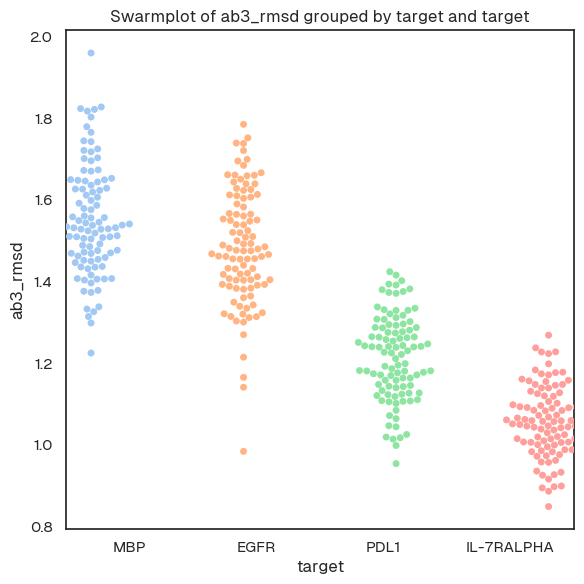


Group Statistics (mean ± std):
    target  mean   std
      EGFR 1.485 0.143
IL-7RALPHA 1.059 0.085
       MBP 1.552 0.135
      PDL1 1.215 0.104


In [42]:
plot_swarm_with_stats(structure_results, x_col="target", y_col="ab3_rmsd", hue_col="target")

We can see that the mean RMSD difference between each variant is above 1 A with standard deviations for the targets ranging from 0.085 to 0.14. This self consistency score can be seen to some extent as a proxy for how well the inversefolding model worked. Do the new variants adopt a similar fold and conformation to the parent. One thing to consider is the flexible nature of the CDR regions however, and often the unbound and bound shape of these regions can be different. Therefore cofolding against the target should provide a better proxy for "binding" than free antibody prediction. 

In [28]:
immunefold_inputs = []
for i, row in samples_df[samples_df["target"] == "EGFR"].iterrows():

    h = row["heavy"]
    l = row["light"]
    target = row["target"]
    target_pdb = target_pdbs_target_only[target]

    
    
    immunefold_inputs.append({"H": h, "L": l, "pdb": target_pdb})
def batch_list(lst, n):
    """
    Split a list into chunks of size n.

    Args:
        lst (list): The list to split.
        n (int): The batch size.

    Returns:
        list of lists: A list where each sublist has at most n elements.
    """
    return [lst[i:i + n] for i in range(0, len(lst), n)]

immunefold_inputs = batch_list(immunefold_inputs, 1)

immunefold_outputs = BioLM(entity="immunefold-antibody", action="predict", items=immunefold_inputs[:10])

Visualizing the outputs of immunefold we see the antibody in compelx with Extracellular Domain III of EGFR. Similar RMSD calculations like those demonstrated with AbodyBuilder can be used and since the output is in complex the predicted structure can be compared to the *solved* structures used as the original input. Interface calculations, MD and perturbation methods can also be used on the complex similar to pipelines used after docking methods. A caviat is that any downstream analysis depends on the accuracy and confidence of the predicted structure. If binding site and binding orientation are incorrect, antibody and antigen structure analysis can be very misleading. Thus confidence metrics such as PLDDT and PTM can be useful in slecting appropriate structures for further analysis and in fact, in some cases been used as thresholds for binder selection. Because of this physics based analysis of predicted complexes remains a robust approach as relaxation, potentials and other techniques can help ensure the validity and quality of the complex.

In [37]:
view = py3Dmol.view(js='https://3Dmol.org/build/3Dmol-min.js', width=800, height=400)
view.addModel(immunefold_outputs[0]["pdb"], 'pdb')
view.setStyle({'model': -1}, {"cartoon": {'color': 'spectrum'}})
view.zoomTo()

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol